# Personalized Medicine Recommendation System

This notebook builds a machine learning model to recommend drugs for patients based on their clinical and genetic profiles. We use a Random Forest classifier trained on a pharmacogenomic dataset.

## 1. Setup and Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 35)

## 2. Loading the Dataset

The dataset contains 300,000 patient records with 47 features covering clinical info (age, BMI, conditions), genetic markers, and pharmacogenomic scores.

In [9]:
combined_df = pd.read_csv('../data/medical_genetic_PHARMACOGENOMIC_enhanced.csv')

print(f'Dataset shape: {combined_df.shape}')
print(f'Number of features: {combined_df.shape[1]}')
combined_df.head()

Dataset shape: (300000, 47)
Number of features: 47


,Age,Gender,Diabetes,Hypertension,Cholesterol,BMI,Heart_Disease,Asthma,Thyroid,Infection,Smoking_Status,Alcohol_Intake,Blood_Pressure,Heart_Rate,Recommended_Drug,Treatment_Type,HbA1c,...,CYP2C19_Metabolism,Genetic_Risk_Score,Family_History_Cancer,Family_History_Heart,Inflammation_Gene,Metabolism_Gene,DNA_Repair_Gene,Drug_Response_Gene,Genetic_Disorder_Flag,Polygenic_Risk_Index,Clopidogrel_Metabolism_Score,Drug_Efficacy_Multiplier,Hepatic_Metabolism_Rate,Statin_Response_Score,Anti_Inflammatory_Response,Genetic_Drug_Match_Score,Genetic_Contraindication_Flag
0,69,Male,1,0,164,30.4,0,0,0,0,Never,High,172,78,Metformin,Medication,7.4,...,Poor,0.181,1,0,0,0,1,High,1,0.830,0.11,0.92,0.50,0.69,0.45,0.877,0
1,20,Female,1,0,171,19.0,0,0,0,0,Former,Moderate,91,118,Metformin,Medication,8.9,...,Intermediate,0.584,1,1,1,0,0,Low,0,0.474,0.59,0.52,0.58,0.91,0.78,0.432,0
2,77,Female,1,0,170,28.5,0,0,0,0,Former,NaN,178,103,Metformin,Medication,8.3,...,Poor,0.049,0,1,1,0,0,Moderate,0,0.367,0.22,0.73,0.88,0.91,0.89,0.562,0
3,76,Female,1,0,191,18.8,0,0,0,0,Current,Moderate,151,101,Metformin,Medication,8.0,...,Intermediate,0.593,1,0,0,1,1,Moderate,0,0.974,0.48,0.79,1.52,0.50,0.45,0.536,0
4,79,Female,1,0,200,24.5,0,0,0,0,Never,High,140,61,Metformin,Medication,6.9,...,Normal,0.329,1,0,1,0,0,Moderate,0,0.077,0.64,0.88,0.55,0.40,0.79,0.716,0


## 3. Exploring the Target Variable

Let's look at how the drug recommendations are distributed across the dataset.

Drug distribution:
Recommended_Drug
Metformin        20000
Insulin          20000
Amlodipine       20000
Losartan         20000
Atorvastatin     20000
Rosuvastatin     20000
Aspirin          20000
Clopidogrel      20000
Orlistat         20000
Levothyroxine    20000
Salbutamol       20000
Omeprazole       20000
Paracetamol      20000
Amoxicillin      20000
No Drug          20000
Name: count, dtype: int64

Number of drug classes: 15


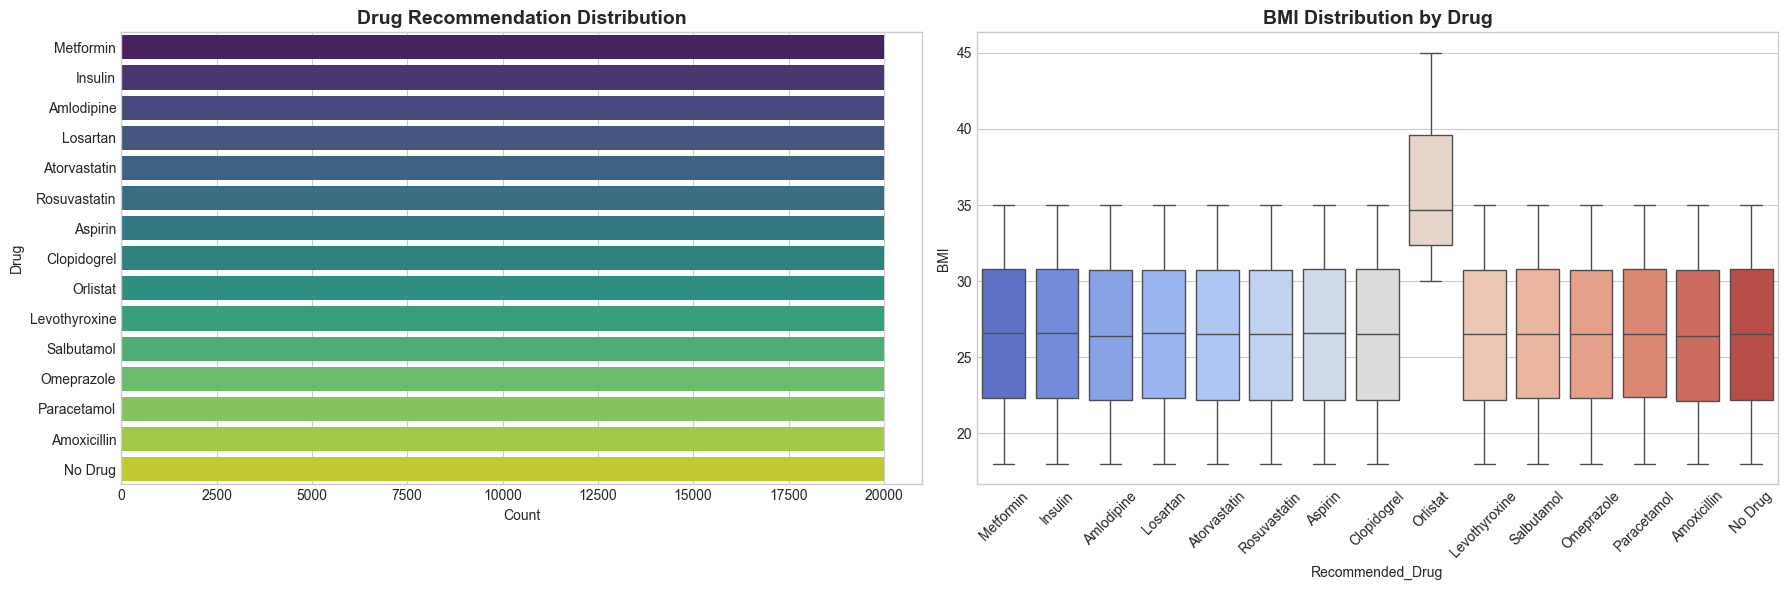


Min class count: 20000
Max class count: 20000
Note: The classes are perfectly balanced, which suggests synthetic data.
Results here should not be used for actual clinical decisions.


In [10]:
df = combined_df.copy()

print('Drug distribution:')
print(df['Recommended_Drug'].value_counts())
print(f'\nNumber of drug classes: {df["Recommended_Drug"].nunique()}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# count plot
sns.countplot(
    data=df, y='Recommended_Drug',
    order=df['Recommended_Drug'].value_counts().index,
    ax=axes[0], palette='viridis'
)
axes[0].set_title('Drug Recommendation Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Drug')

# BMI by drug
sns.boxplot(
    data=df, x='Recommended_Drug', y='BMI',
    ax=axes[1], palette='coolwarm'
)
axes[1].set_title('BMI Distribution by Drug', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# quick check — is the data perfectly balanced?
class_counts = df['Recommended_Drug'].value_counts()
print(f'\nMin class count: {class_counts.min()}')
print(f'Max class count: {class_counts.max()}')
if class_counts.min() == class_counts.max():
    print('Note: The classes are perfectly balanced, which suggests synthetic data.')
    print('Results here should not be used for actual clinical decisions.')

## 4. Data Preprocessing

We drop Patient_ID (not useful for prediction) and Treatment_Type (could leak information about the target). Then we handle missing values and encode categorical features.

In [11]:
# drop columns that would cause issues
df.drop('Patient_ID', axis=1, inplace=True)

if 'Treatment_Type' in df.columns:
    df.drop('Treatment_Type', axis=1, inplace=True)
    print('Dropped Treatment_Type to avoid data leakage.')

# fill missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# separate features and target
X = df.drop('Recommended_Drug', axis=1)
y = df['Recommended_Drug']

# one-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

feature_columns = X.columns.tolist()

print(f'Features shape after encoding: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Number of feature columns: {len(feature_columns)}')

Dropped Treatment_Type to avoid data leakage.
Features shape after encoding: (300000, 49)
Target shape: (300000,)
Number of feature columns: 49


## 5. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 240000
Testing samples:  60000


## 6. Feature Engineering and Model Training

Before training, we create a few interaction features that combine genetic and clinical information. Then we train a Random Forest with 400 trees.

In [13]:
# create some interaction features
combined_df['Genetic_HbA1c_Int'] = combined_df['Genetic_Drug_Match_Score'] * (combined_df['HbA1c'] / 10)
combined_df['Genetic_eGFR_Int'] = combined_df['Genetic_Drug_Match_Score'] * (combined_df['eGFR'] / 100)
combined_df['DrugEff_BMI_Int'] = combined_df['Drug_Efficacy_Multiplier'] * (combined_df['BMI'] / 30)
combined_df['Metabolism_LDL_Int'] = combined_df['Hepatic_Metabolism_Rate'] * (combined_df['LDL_Cholesterol'] / 100)

# weighted pharmacogenomic score
combined_df['Pharma_Score_Combo'] = (
    combined_df['Genetic_Drug_Match_Score'] * 0.4 +
    combined_df['Drug_Efficacy_Multiplier'] * 0.3 +
    combined_df['Statin_Response_Score'] * 0.15 +
    combined_df['Clopidogrel_Metabolism_Score'] * 0.15
)

# re-prepare features with the new columns
y = combined_df['Recommended_Drug']
X = combined_df.drop(['Recommended_Drug', 'Treatment_Type', 'Patient_ID'], axis=1, errors='ignore')
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# train the model
model_optimized = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model_optimized.fit(X_train, y_train)
print('Model training done.')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   39.4s


Model training done.


[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:  1.4min finished


## 7. Predictions

Let's generate predictions on the test set and look at a few examples.

In [14]:
y_pred = model_optimized.predict(X_test)

print('Sample predictions (first 10):')
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
display(comparison)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.0s


Sample predictions (first 10):


[Parallel(n_jobs=8)]: Done 400 out of 400 | elapsed:    2.1s finished


,Actual,Predicted
0,Insulin,Insulin
1,Amoxicillin,Amoxicillin
2,Levothyroxine,Levothyroxine
3,Clopidogrel,Clopidogrel
4,No Drug,No Drug
5,Rosuvastatin,Rosuvastatin
6,Clopidogrel,Clopidogrel
7,Orlistat,Orlistat
8,Omeprazole,Omeprazole
9,Salbutamol,Salbutamol


## 8. Model Evaluation

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

Accuracy:  0.8464 (84.64%)
Precision: 0.8494
Recall:    0.8464
F1 Score:  0.8451


## 9. Feature Importance

Which features matter the most for the model's predictions?

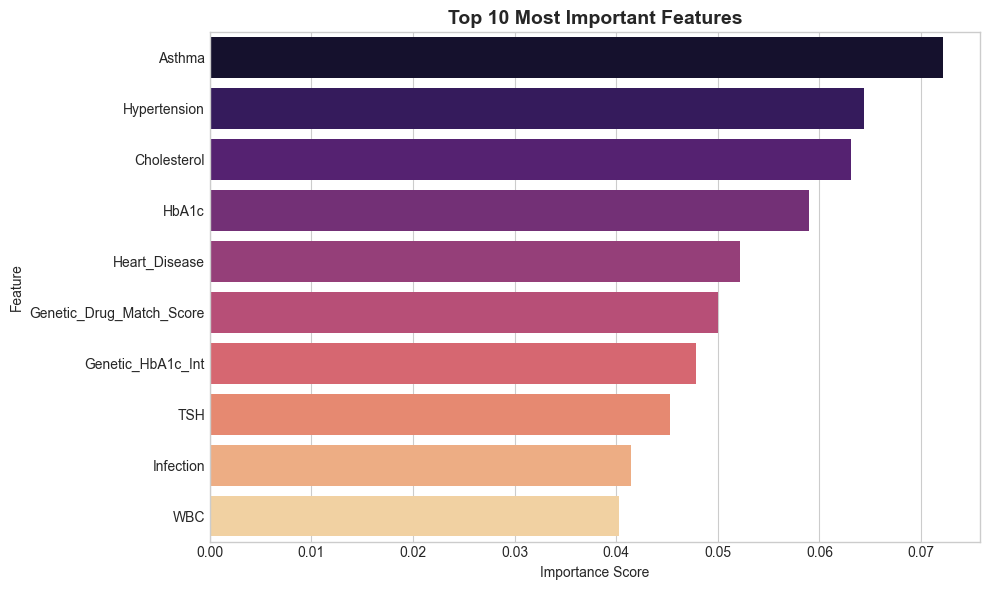


Top 10 features:


,Feature,Importance
0,Asthma,0.072192
1,Hypertension,0.064348
2,Cholesterol,0.063096
3,HbA1c,0.059001
4,Heart_Disease,0.052185
5,Genetic_Drug_Match_Score,0.050037
6,Genetic_HbA1c_Int,0.047832
7,TSH,0.045310
8,Infection,0.041430
9,WBC,0.040269


In [16]:
importances = model_optimized.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_encoded.columns.tolist(),
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_10 = feature_imp_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_10, x='Importance', y='Feature',
    palette='magma', ax=ax
)
ax.set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
display(top_10.reset_index(drop=True))